In [1]:
from moabb.datasets import *
from moabb.paradigms import P300

dataset = BNCI2014_008()
paradigm = P300(resample=32)
epochs, labels, meta = paradigm.get_data(
    dataset,
    subjects=[1],
    return_epochs=True,
)

/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


No projector specified for this dataset. Please consider the method self.add_proj.


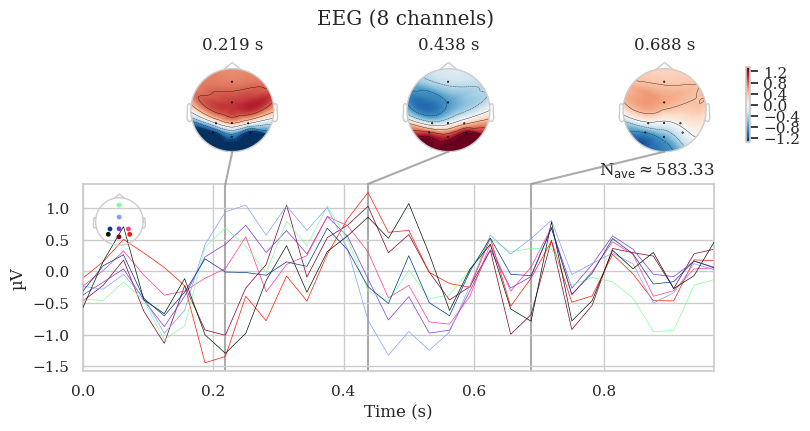

In [2]:
from mne import combine_evoked

contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])
contrast.plot_joint();

In [3]:
import tensorly as tl
from bttda.classification import ZScore

X = tl.tensor(epochs.get_data()*1e6)
y = labels
X.shape

(4200, 8, 32)

In [4]:
from bttda.hoda import HODA

hoda = HODA(
        shrinkage='lw',
        obj='tr',
        toeplitz=(1,),
        extra_train_info=True,
        verbose=True,
        theta=0.2,
)


In [5]:
import pandas as pd

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])

Backward HODA model rank=(1, 4):   7%|▋         | 18/256 [00:00<00:08, 28.50it/s]


In [6]:
df

,iteration,mode,flip,update,shrinkage,objective,F_tr,F_rt
0,1,1,1,7.834146e-01,0.000239,3.861591e+07,0.000864,0.000002
1,1,2,2,1.436559e+00,0.023262,4.049800e+06,0.014067,0.000009
2,2,1,3,7.314912e-01,0.000239,1.540065e+07,0.029344,0.000020
3,2,2,4,3.584976e-01,0.023262,2.759038e+06,0.068842,0.000051
4,3,1,5,4.616784e-01,0.000239,3.890202e+06,0.132988,0.000102
5,3,2,6,1.889017e-01,0.023262,2.531429e+06,0.150120,0.000118
6,4,1,7,3.652690e-01,0.000239,1.667258e+06,0.191678,0.000154
7,4,2,8,1.310499e-01,0.023262,2.573989e+06,0.196781,0.000158
8,5,1,9,1.538547e-01,0.000239,1.102781e+06,0.207612,0.000169
9,5,2,10,1.009015e+00,0.023262,2.748011e+06,0.209981,0.000170


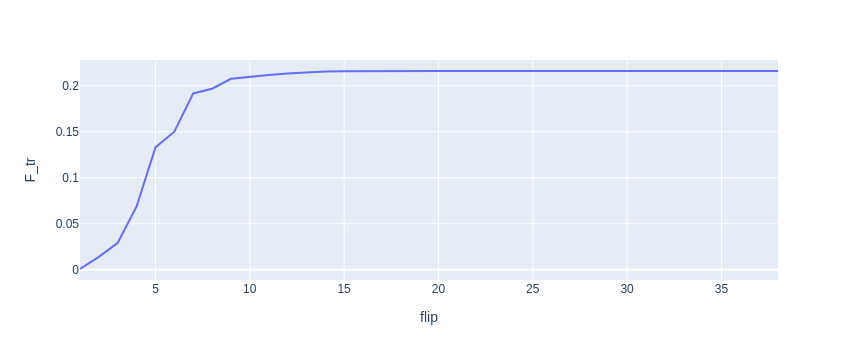

In [7]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr')
    fig.show()


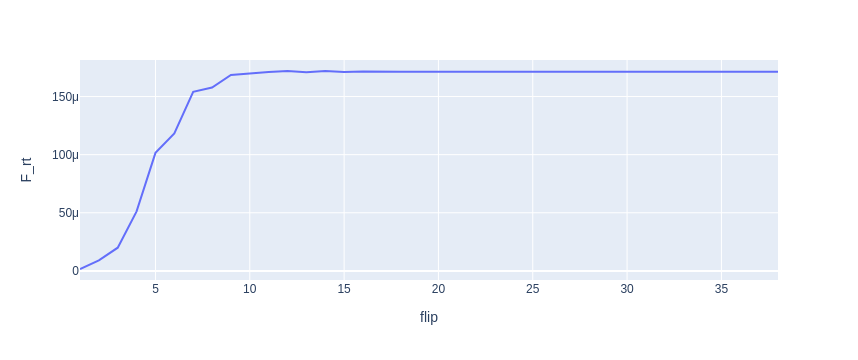

In [8]:
if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_rt')
    fig.show()

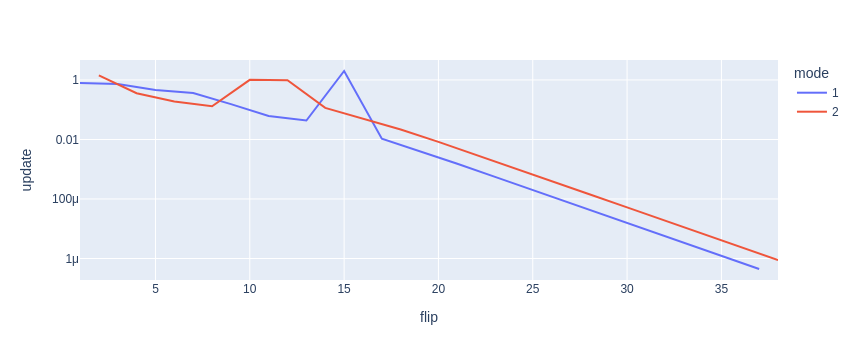

In [9]:
px.line(df, x='flip', y='update', log_y=True, color='mode')


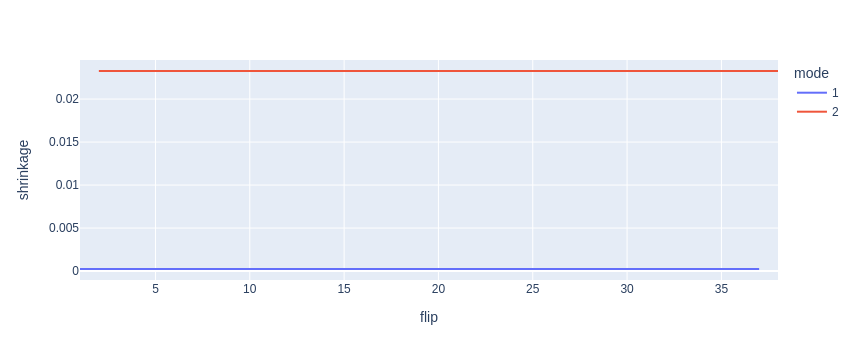

In [10]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

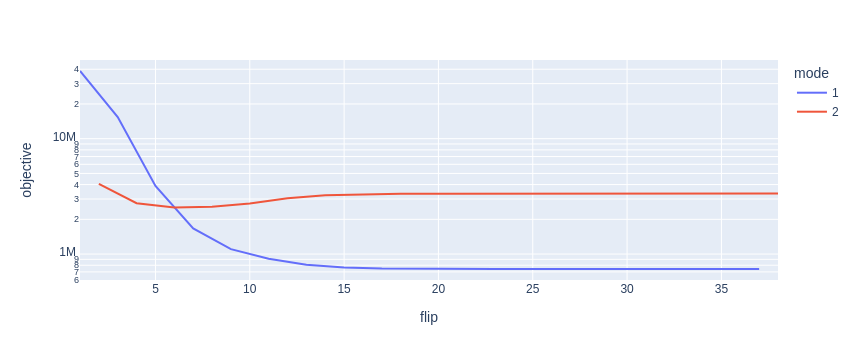

In [11]:
px.line(df, x='flip', y='objective', log_y=True, color='mode')

In [12]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model :  16%|█▋        | 42/255 [00:00<00:02, 77.62it/s]


,iteration,mode,flip,update,lambda_,mse,nmse
0,1,1,1,1.079382e+00,0.0,79.048624,0.998247
1,1,2,2,6.475971e-01,0.0,79.022146,0.997912
2,2,1,3,1.291947e-01,0.0,79.019386,0.997877
3,2,2,4,3.074515e-01,0.0,79.016158,0.997837
4,3,1,5,1.511652e-01,0.0,79.012243,0.997787
...,...,...,...,...,...,...,...
81,41,2,82,7.677610e-07,0.0,78.965739,0.997200
82,42,1,83,1.022629e-06,0.0,78.965739,0.997200
83,42,2,84,5.471359e-07,0.0,78.965739,0.997200
84,43,1,85,7.287658e-07,0.0,78.965739,0.997200


In [13]:
if hoda.extra_train_info:
    px.line(df, x='flip', y='mse', log_y=True)

In [14]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

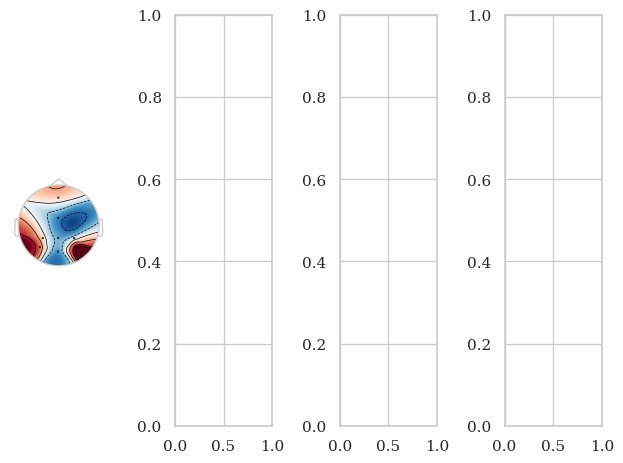

In [15]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

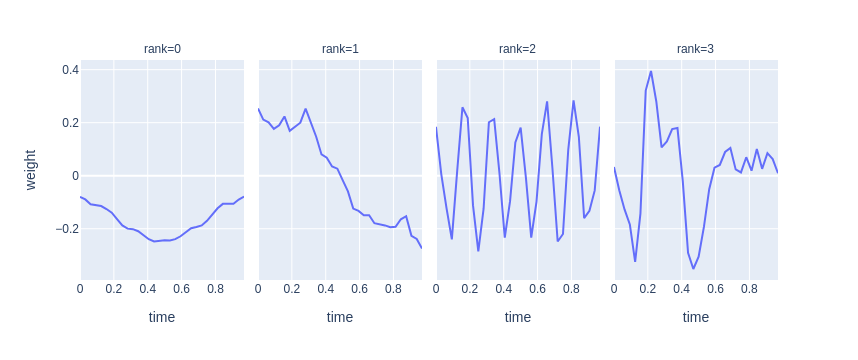

In [16]:
from mne.viz import plot_topomap
from plotly.tools import mpl_to_plotly

# TODO spatial weights
df = pd.DataFrame(tl.to_numpy(hoda.weights_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='weight')
px.line(df, x='time', y='weight', facet_col='rank', facet_col_wrap=4)

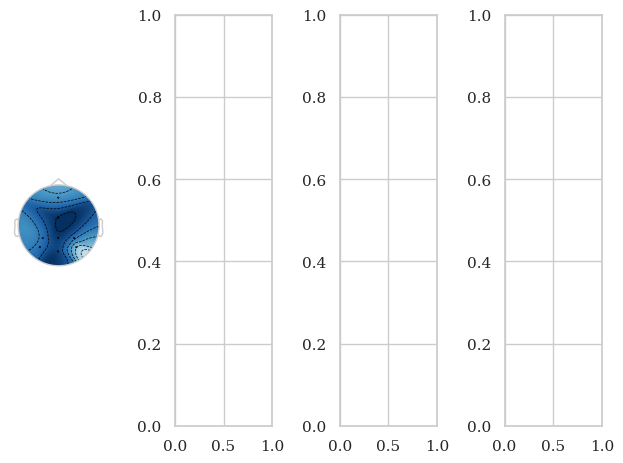

In [17]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])


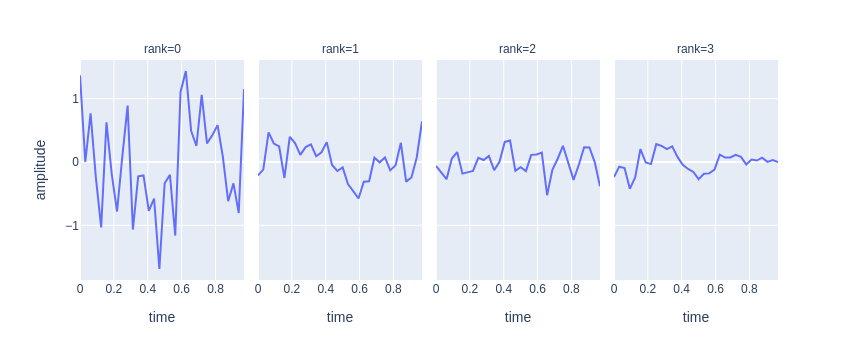

In [18]:
df = pd.DataFrame(tl.to_numpy(hoda.aps_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='amplitude')
px.line(df, x='time', y='amplitude', facet_col='rank', facet_col_wrap=4)

In [19]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from bttda.classification import SelectFCutoff

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFCutoff()
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'significant': select.scores_>1,
})
df

,feature,F,significant
0,0,1.168395,True
1,1,69.796128,True
2,2,0.021906,False
3,3,795.200298,True


In [20]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

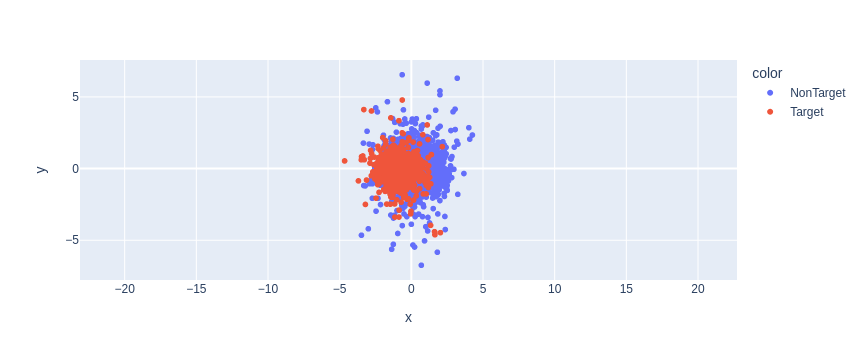

In [21]:
from sklearn.decomposition import PCA

x_viz = PCA(n_components=2, whiten=True).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
  )

In [22]:
from bttda.hoda import f_multiway

print(f"trace-ratio: {f_multiway(xts,y, method='tr')}")
print(f"ratio-trace: {f_multiway(xts,y, method='rt')}")

trace-ratio: 0.2742837217949813
ratio-trace: 0.00017123540735337265
